In [11]:
import sys
from pathlib import Path
root_dir = Path('./notebook').resolve().parent.parent
sys.path.append(str(root_dir))

from scripts.util import db_connection
import pandas as pd

db = db_connection('../warehouse/instacart.duckdb')
print("Connected to DuckDB database successfully.")

Connected to DuckDB database successfully.


**Before you proceed please validate via terminal**
1. go run `python scripts/validate_database_schema.py`
2. go run `python scripts/validate_database_key_rs.py`

In [2]:
orders_by_day = db.sql("""
    select
        order_dow,
        count(distinct order_id) as order_count
    from fact_order_items
    group by order_dow
    order by order_dow
""").df()

**Quick view on the:**
1. order table
2. product table
3. department table

In [3]:
top_products = db.sql("""
    select
        p.product_name,
        count(*) as item_count,
        avg(f.reordered) as reorder_rate
    from fact_order_items f
    join dim_products p
        on f.product_id = p.product_id
    group by p.product_name
    order by item_count desc
    limit 20
""").df()

In [4]:
department_summary = db.sql("""
    select
        d.department_name,
        count(*) as item_count,
        avg(f.reordered) as reorder_rate
    from fact_order_items f
    join dim_departments d
        on f.department_id = d.department_id
    group by d.department_name
    order by item_count desc
""").df()

## Business Insights: Macro to Micro

This section works from department-level totals down to individual products, then closes with cart-position timing:

1. Top departments by items ordered and reordered items
2. Top items and reordered items within the top 5 departments
3. Order volume by department and day of week — a timing view for promotions
4. Average add-to-cart position by department (earlier vs. later adds)
5. Average add-to-cart position by product — top 10 earliest vs. top 10 latest

**Data note:** this dataset has no prices, quantities, calendar dates, or customer demographics, so these are volume/behavior/timing metrics only, not revenue metrics.

In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

BLUE = "#2a78d6"     # items ordered / earlier-added / below-median
ORANGE = "#eb6834"   # reordered items / later-added / above-median
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"
BLUE_SEQUENTIAL = LinearSegmentedColormap.from_list(
    "blue_sequential", ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]
)


def _style_axes(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_color(MUTED)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(colors=MUTED)


def bar_chart(x, y, color, title, xlabel, ylabel, value_fmt="{:,.0f}", rotate_x=0, figsize=None):
    figsize = figsize or (max(8, 0.4 * len(x)), 4.5)
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(x, y, color=color, width=0.6)

    ax.set_title(title, color=INK, fontsize=12, loc="left")
    ax.set_xlabel(xlabel, color=MUTED)
    ax.set_ylabel(ylabel, color=MUTED)
    _style_axes(ax)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

    if rotate_x:
        plt.setp(ax.get_xticklabels(), rotation=rotate_x, ha="right")

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            value_fmt.format(height),
            (bar.get_x() + bar.get_width() / 2, height),
            ha="center", va="bottom", fontsize=9, color=INK,
        )

    plt.tight_layout()
    plt.show()


def diverging_bar_chart(labels, values, colors, legend, title, xlabel, ylabel, value_fmt="{:,.1f}"):
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(labels))))
    bars = ax.barh(labels, values, color=colors, height=0.6)
    ax.invert_yaxis()

    ax.set_title(title, color=INK, fontsize=12, loc="left")
    ax.set_xlabel(xlabel, color=MUTED)
    ax.set_ylabel(ylabel, color=MUTED)
    _style_axes(ax)
    ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            value_fmt.format(width),
            (width, bar.get_y() + bar.get_height() / 2),
            ha="left", va="center", fontsize=9, color=INK,
        )

    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in legend.values()]
    ax.legend(handles, legend.keys(), frameon=False, loc="lower right")

    plt.tight_layout()
    plt.show()


def heatmap_chart(pivot_df, title, xlabel, ylabel, cbar_label):
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(pivot_df))))
    im = ax.imshow(pivot_df.values, cmap=BLUE_SEQUENTIAL, aspect="auto")

    ax.set_xticks(range(len(pivot_df.columns)))
    ax.set_xticklabels(pivot_df.columns, color=MUTED)
    ax.set_yticks(range(len(pivot_df.index)))
    ax.set_yticklabels(pivot_df.index, color=MUTED)
    ax.set_title(title, color=INK, fontsize=12, loc="left")
    ax.set_xlabel(xlabel, color=MUTED)
    ax.set_ylabel(ylabel, color=MUTED)
    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label, color=MUTED)
    cbar.ax.tick_params(colors=MUTED)

    plt.tight_layout()
    plt.show()

### 1. Top departments by items ordered and reordered items

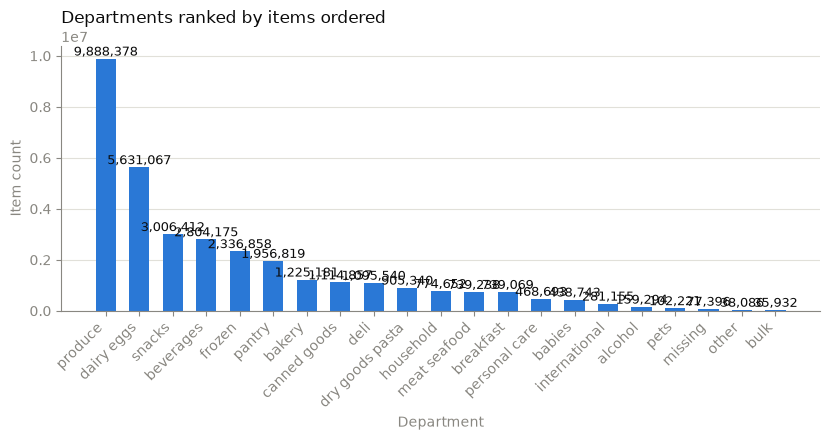

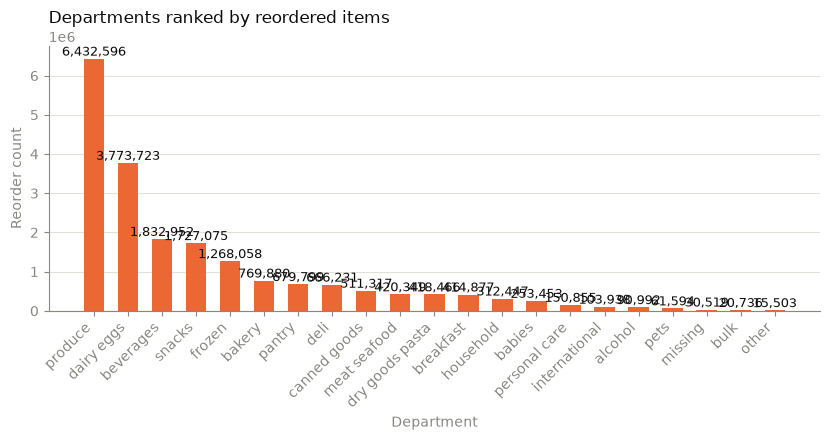

,department_name,item_count,reorder_count
0,produce,9888378,6432596.0
1,dairy eggs,5631067,3773723.0
2,snacks,3006412,1727075.0
3,beverages,2804175,1832952.0
4,frozen,2336858,1268058.0
5,pantry,1956819,679799.0
6,bakery,1225181,769880.0
7,canned goods,1114857,511317.0
8,deli,1095540,666231.0
9,dry goods pasta,905340,418466.0


In [13]:
dept_order_counts = db.sql("""
    select
        d.department_name,
        count(*) as item_count,
        sum(f.reordered) as reorder_count
    from fact_order_items f
    join dim_departments d
        on f.department_id = d.department_id
    group by d.department_name
    order by item_count desc
""").df()

bar_chart(
    dept_order_counts["department_name"],
    dept_order_counts["item_count"],
    color=BLUE,
    title="Departments ranked by items ordered",
    xlabel="Department",
    ylabel="Item count",
    rotate_x=45,
)

dept_by_reorder = dept_order_counts.sort_values("reorder_count", ascending=False)
bar_chart(
    dept_by_reorder["department_name"],
    dept_by_reorder["reorder_count"],
    color=ORANGE,
    title="Departments ranked by reordered items",
    xlabel="Department",
    ylabel="Reorder count",
    rotate_x=45,
)

dept_order_counts

### 2. Top items and reordered items within the top 5 departments

Drilling into the 5 departments with the most items ordered (from the ranking above), showing each department's own top 5 products by item count and by reorder count.

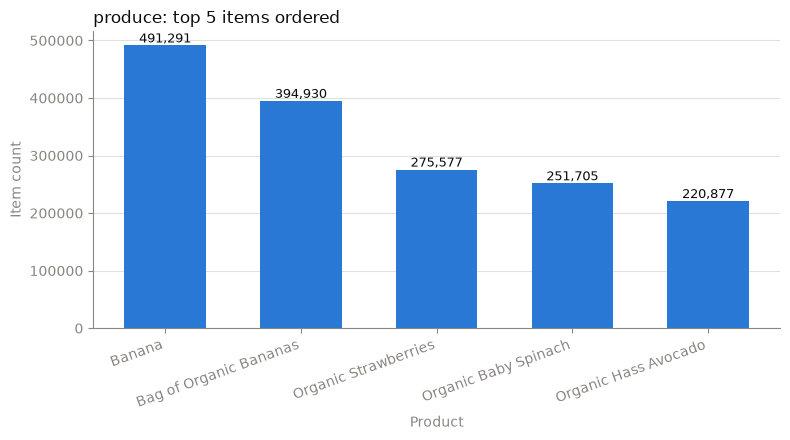

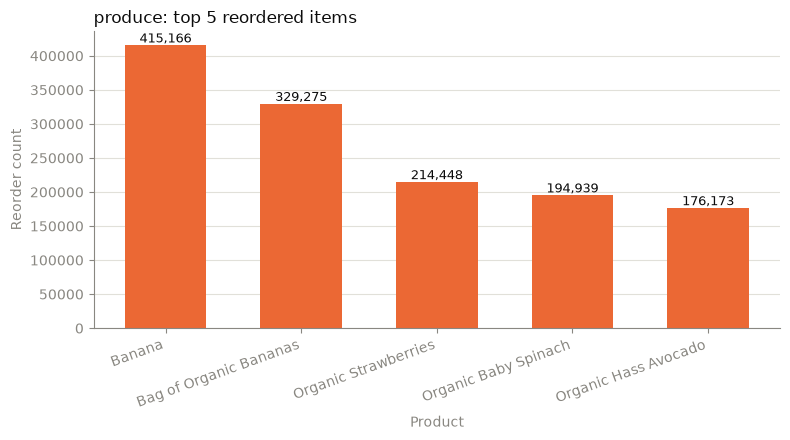

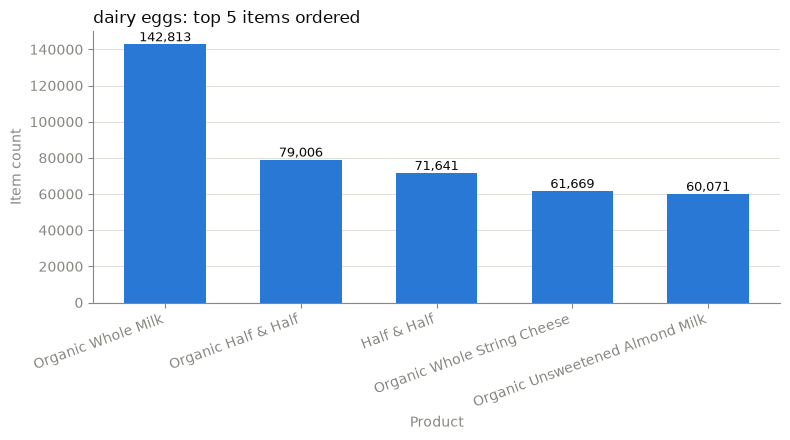

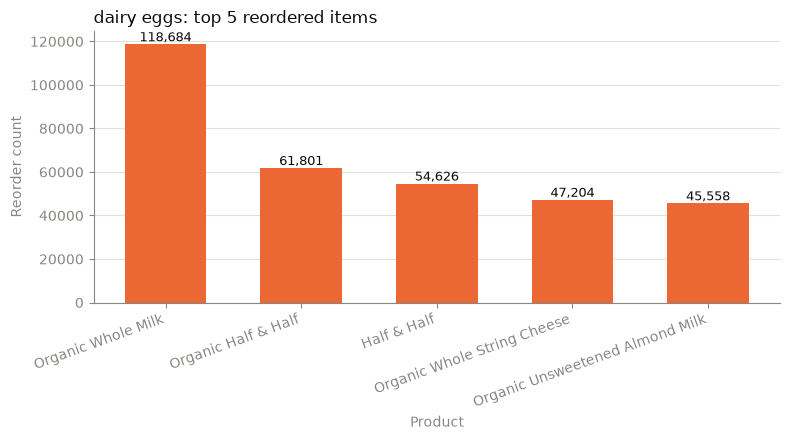

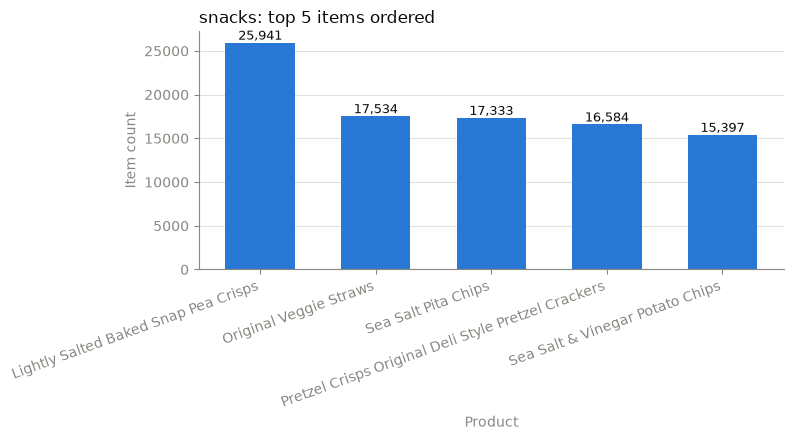

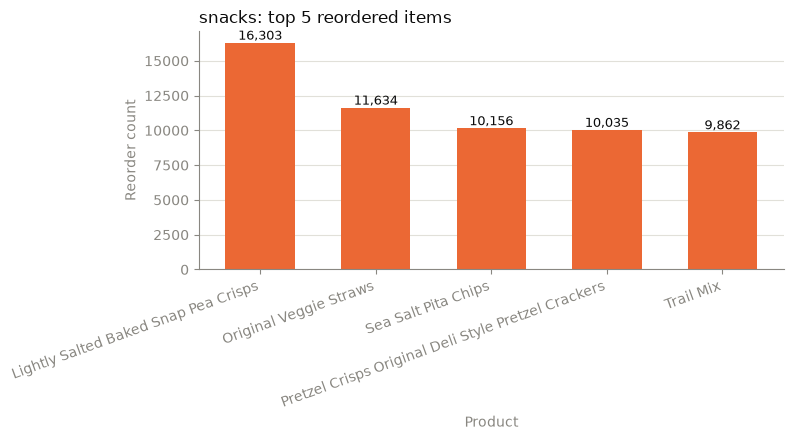

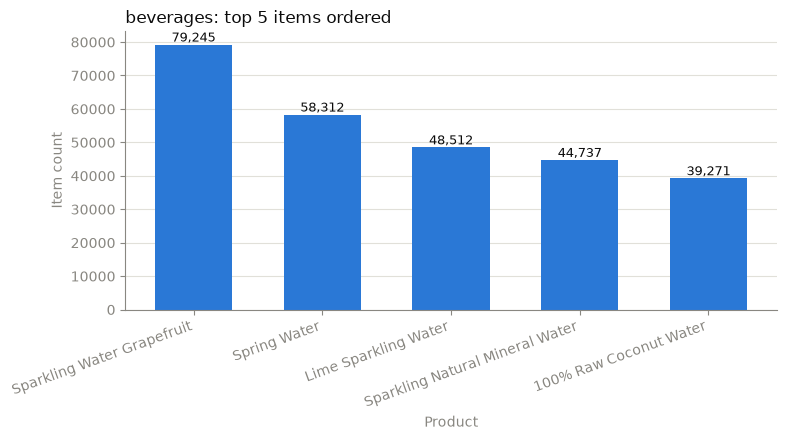

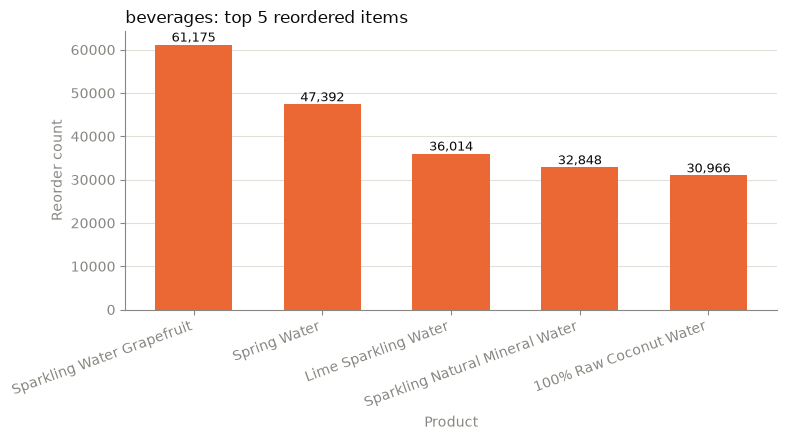

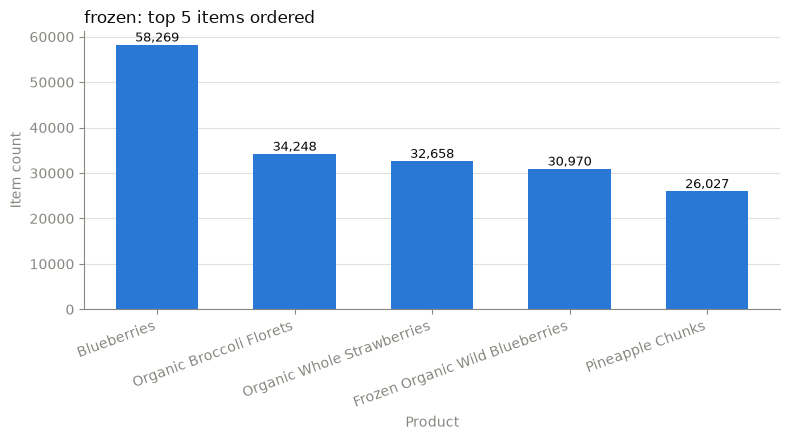

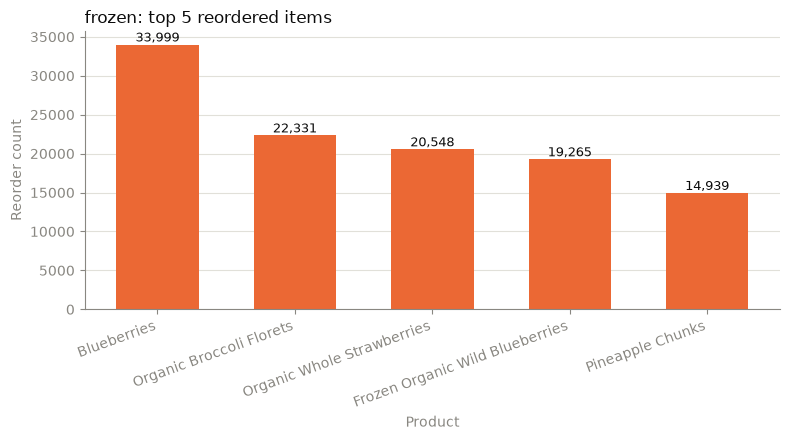

In [14]:
top5_departments = dept_order_counts["department_name"].head(5).tolist()
dept_list_sql = ", ".join(f"'{d}'" for d in top5_departments)

dept_product_agg = db.sql(f"""
    select
        d.department_name,
        p.product_name,
        count(*) as item_count,
        sum(f.reordered) as reorder_count
    from fact_order_items f
    join dim_products p on f.product_id = p.product_id
    join dim_departments d on f.department_id = d.department_id
    where d.department_name in ({dept_list_sql})
    group by d.department_name, p.product_name
""").df()

for dept in top5_departments:
    dept_slice = dept_product_agg[dept_product_agg["department_name"] == dept]

    top_items = dept_slice.nlargest(5, "item_count")
    bar_chart(
        top_items["product_name"], top_items["item_count"],
        color=BLUE, title=f"{dept}: top 5 items ordered",
        xlabel="Product", ylabel="Item count", rotate_x=20,
    )

    top_reordered = dept_slice.nlargest(5, "reorder_count")
    bar_chart(
        top_reordered["product_name"], top_reordered["reorder_count"],
        color=ORANGE, title=f"{dept}: top 5 reordered items",
        xlabel="Product", ylabel="Reorder count", rotate_x=20,
    )

### 3. Order volume by department and day of week — timing for a sale

**Data limitation:** `order_dow` is a numeric code (0–6) from the raw Instacart export. Instacart has not published an official mapping from this code to an actual weekday name, so results are reported by **code only** (e.g. "day code 0") rather than an invented weekday label.

Each row below is normalized to the % of that department's own items falling on each day, so departments can be compared on their *pattern* regardless of overall size — the darkest cell in a row marks that department's peak day code. A peak day shows where organic demand is already highest; whether a sale should reinforce that day or target a slower one is a business call this data can inform but not decide on its own.

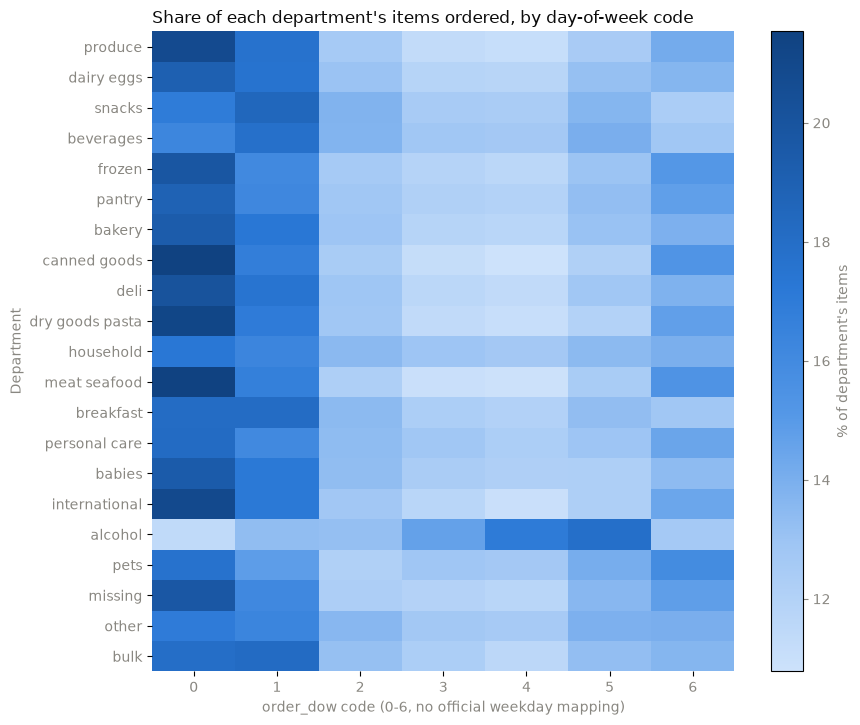

,department_name,peak_order_dow_code
16,alcohol,5
14,babies,0
6,bakery,0
3,beverages,1
12,breakfast,1
20,bulk,1
7,canned goods,0
1,dairy eggs,0
8,deli,0
9,dry goods pasta,0


In [15]:
dept_dow = db.sql("""
    select
        d.department_name,
        f.order_dow,
        count(*) as item_count
    from fact_order_items f
    join dim_departments d
        on f.department_id = d.department_id
    group by d.department_name, f.order_dow
""").df()

dept_dow_pivot = dept_dow.pivot(index="department_name", columns="order_dow", values="item_count").fillna(0)
dept_dow_pivot = dept_dow_pivot.loc[dept_dow_pivot.sum(axis=1).sort_values(ascending=False).index]
dept_dow_share = dept_dow_pivot.div(dept_dow_pivot.sum(axis=1), axis=0) * 100

heatmap_chart(
    dept_dow_share,
    title="Share of each department's items ordered, by day-of-week code",
    xlabel="order_dow code (0-6, no official weekday mapping)",
    ylabel="Department",
    cbar_label="% of department's items",
)

peak_day_by_department = (
    dept_dow_pivot.idxmax(axis=1)
    .rename("peak_order_dow_code")
    .reset_index()
    .sort_values("department_name")
)
peak_day_by_department

### 4. Add-to-cart timing by department

Average `add_to_cart_order` per department — a lower number means items from that department tend to be dropped into the basket earlier in the shopping trip.

In [ ]:
dept_atc = db.sql("""
    select
        d.department_name,
        avg(f.add_to_cart_order) as avg_add_to_cart_order,
        count(*) as item_count
    from fact_order_items f
    join dim_departments d
        on f.department_id = d.department_id
    group by d.department_name
    order by avg_add_to_cart_order
""").df()

overall_median_atc = dept_atc["avg_add_to_cart_order"].median()
dept_atc_colors = [BLUE if v <= overall_median_atc else ORANGE for v in dept_atc["avg_add_to_cart_order"]]

diverging_bar_chart(
    dept_atc["department_name"],
    dept_atc["avg_add_to_cart_order"],
    dept_atc_colors,
    legend={"Below median (added earlier)": BLUE, "Above median (added later)": ORANGE},
    title="Average add-to-cart position by department",
    xlabel="Avg add-to-cart position",
    ylabel="Department",
)

dept_atc

### 5. Add-to-cart timing by product

Same question at the product level, limited to the 10 products added earliest and 10 added latest on average (out of ~50k products) to keep the chart readable. `item_count` is shown alongside each average so low-volume products (whose average can be noisy) are visible rather than hidden.

In [ ]:
product_atc_earliest = db.sql("""
    select
        p.product_name,
        avg(f.add_to_cart_order) as avg_add_to_cart_order,
        count(*) as item_count
    from fact_order_items f
    join dim_products p on f.product_id = p.product_id
    group by p.product_name
    order by avg_add_to_cart_order asc
    limit 10
""").df()

product_atc_latest = db.sql("""
    select
        p.product_name,
        avg(f.add_to_cart_order) as avg_add_to_cart_order,
        count(*) as item_count
    from fact_order_items f
    join dim_products p on f.product_id = p.product_id
    group by p.product_name
    order by avg_add_to_cart_order desc
    limit 10
""").df()

product_atc_earliest["group"] = "earliest"
product_atc_latest["group"] = "latest"
product_atc_combined = pd.concat([product_atc_earliest, product_atc_latest]).sort_values(
    "avg_add_to_cart_order"
)
product_atc_colors = [BLUE if g == "earliest" else ORANGE for g in product_atc_combined["group"]]

diverging_bar_chart(
    product_atc_combined["product_name"],
    product_atc_combined["avg_add_to_cart_order"],
    product_atc_colors,
    legend={"Top 10 earliest": BLUE, "Top 10 latest": ORANGE},
    title="Average add-to-cart position — top 10 earliest vs top 10 latest products",
    xlabel="Avg add-to-cart position",
    ylabel="Product",
)

product_atc_combined[["product_name", "avg_add_to_cart_order", "item_count", "group"]]

![features_engineer](../assets/instacart_feature_engineering_guide.svg)

In [ ]:
#start engineering analysis (see image instructions above)